# 5 — ControlNet: generazione condizionata

Terzo stadio della pipeline. L'LDM curriculum (v5) viene **congelato** e gli si affianca una
**ControlNet 3D**: una copia addestrabile del suo encoder che riceve una maschera di
segmentazione e inietta residui nella UNet a ogni passo di denoising. Il modello base non
cambia: impara solo la ControlNet a *guidare* la generazione verso la maschera richiesta.

**Condizione**: maschera FSL-FAST a 3 tessuti (CSF / materia grigia / materia bianca, piu' lo
sfondo: valori `{0,1,2,3}`), calcolata sui volumi raw `181x217x181` e poi zero-paddata a `256^3`
(il padding di una mappa di label e' esatto, un resampling interpolerebbe le etichette).

**Base congelata**: `outputs/models_v5/ldm_unet_epoch800.pt` — il modello curriculum del
notebook 3, che genera in modo incondizionato. Qui si aggiunge il controllo spaziale.

Questo notebook copre il modello e i risultati **qualitativi**. La valutazione quantitativa
(DSC, selezione del checkpoint, tetto della misura) e' nel notebook 6.

In [1]:
import json
import glob
import os
import numpy as np
import nibabel as nib
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap

GEN_DIR="../data/controlnet_gen_test/epoch100"     # volumi generati sul test (102)
METRICS="../outputs/metrics"

#colormap per le 3 classi di tessuto (0=sfondo trasparente)
TISSUE_CMAP=ListedColormap([(0,0,0,0), (0.85,0.20,0.20,1), (0.20,0.75,0.30,1), (0.25,0.45,0.95,1)])
TISSUE_NAMES=["sfondo", "CSF", "materia grigia", "materia bianca"]

def load(path):
    return np.asarray(nib.load(path).dataobj).astype(np.float32)

def views(vol, idx=128):
    """tre viste ortogonali (sagittale, coronale, assiale) ruotate per la visualizzazione"""
    return [np.rot90(vol[idx,:,:]), np.rot90(vol[:,idx,:]), np.rot90(vol[:,:,idx])]

cases=sorted(glob.glob(f"{GEN_DIR}/*_synth.nii.gz"))
print(f"volumi generati disponibili: {len(cases)}")

volumi generati disponibili: 102


## Curva di training

La ControlNet e' addestrata per 100 epoche sull'LDM congelato, con lo stesso target e la
stessa loss dell'LDM (`target = images - noise`, L1) e timestep campionati **uniformemente**
(il curriculum non serve: la struttura globale e' gia' nei pesi congelati, la ControlNet
impara solo a condizionarla).

La loss parte gia' bassa — la UNet e' addestrata, la ControlNet aggiunge solo il
condizionamento — e cala in modo regolare, con la validation che segue la train a distanza
costante: nessun overfitting.

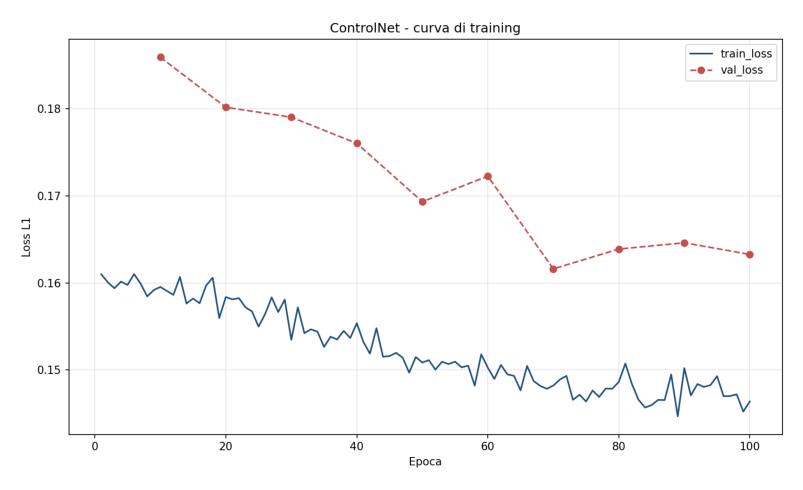

train_loss: 0.1595 (ep10) -> 0.1509 (ep50) -> 0.1464 (ep100)
val_loss:   0.1859 (ep10) -> 0.1693 (ep50) -> 0.1633 (ep100)


In [2]:
fig, ax=plt.subplots(figsize=(11,5))
img=plt.imread(f"{METRICS}/controlnet_loss_curve_v6.png")
ax.imshow(img); ax.axis("off")
plt.tight_layout(); plt.show()

print("train_loss: 0.1595 (ep10) -> 0.1509 (ep50) -> 0.1464 (ep100)")
print("val_loss:   0.1859 (ep10) -> 0.1693 (ep50) -> 0.1633 (ep100)")

## Dalla maschera al volume

La figura chiave: la maschera data come condizione e il volume generato a partire da essa.
Il modello parte da **rumore gaussiano** — non vede mai il volume reale — e deve produrre
un cervello che rispetti la geometria dei tessuti richiesta.

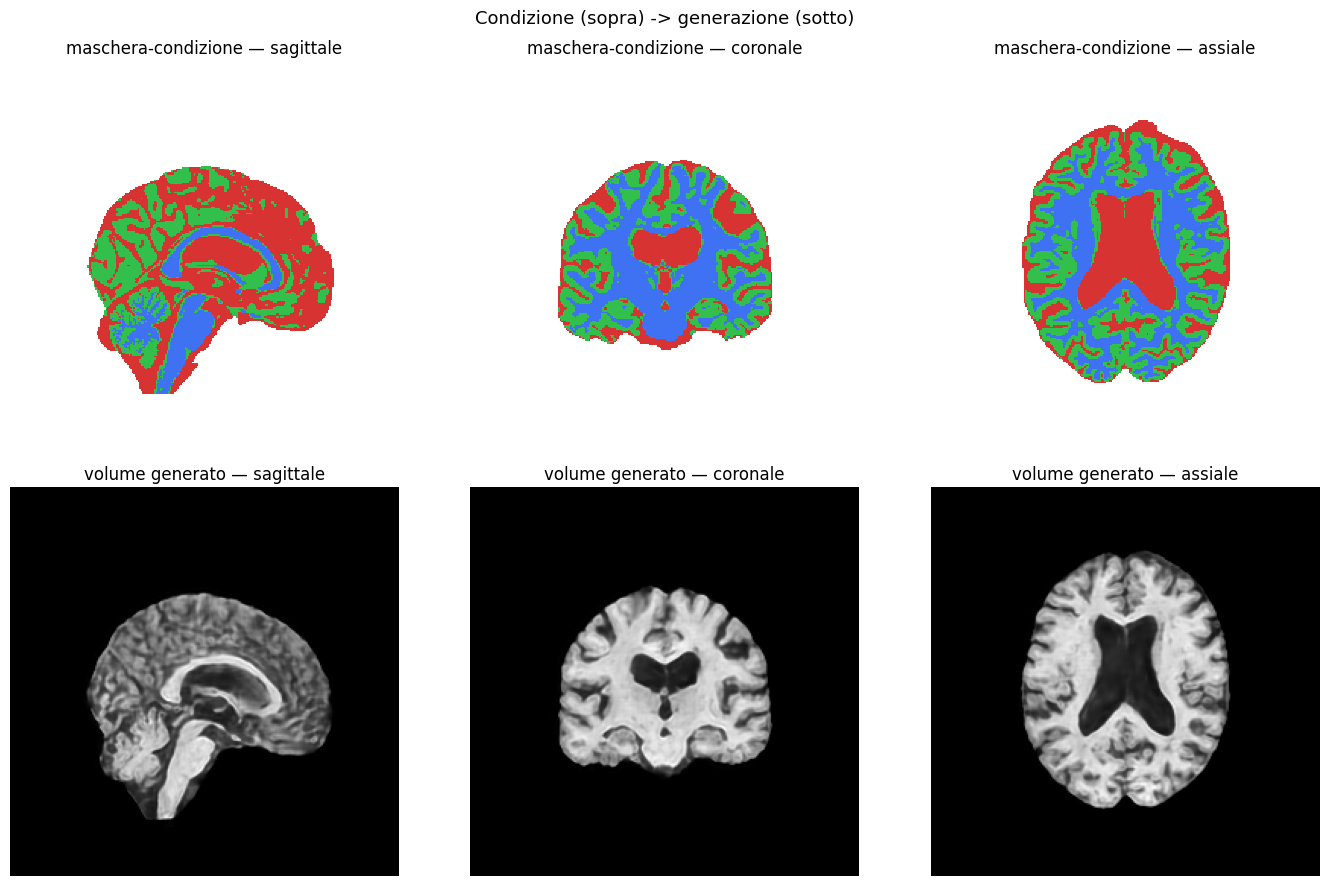

mni_brain_002_S_4262_002_S_4262_002_S_4262_MPRAGE_SENSE_20111005072430


In [3]:
def show_condition_and_result(base, idx=128):
    mask=load(f"{GEN_DIR}/{base}_condmask.nii.gz")
    synth=load(f"{GEN_DIR}/{base}_synth.nii.gz")

    fig, axes=plt.subplots(2, 3, figsize=(14,9))
    for j,(m,s,name) in enumerate(zip(views(mask,idx), views(synth,idx),
                                      ["sagittale","coronale","assiale"])):
        axes[0,j].imshow(m, cmap=TISSUE_CMAP, vmin=0, vmax=3, interpolation="nearest")
        axes[0,j].set_title(f"maschera-condizione — {name}")
        axes[1,j].imshow(s, cmap="gray")
        axes[1,j].set_title(f"volume generato — {name}")
    for a in axes.ravel(): a.axis("off")
    fig.suptitle("Condizione (sopra) -> generazione (sotto)", fontsize=13)
    plt.tight_layout(); plt.show()

base=os.path.basename(cases[0]).replace("_synth.nii.gz","")
show_condition_and_result(base)
print(base)

## Il volume generato con la sua segmentazione sovrapposta

Il volume sintetico viene ri-segmentato con FSL-FAST: l'overlay mostra come i tre tessuti
siano effettivamente distinguibili nel volume generato, e quanto la loro disposizione
segua la maschera richiesta.

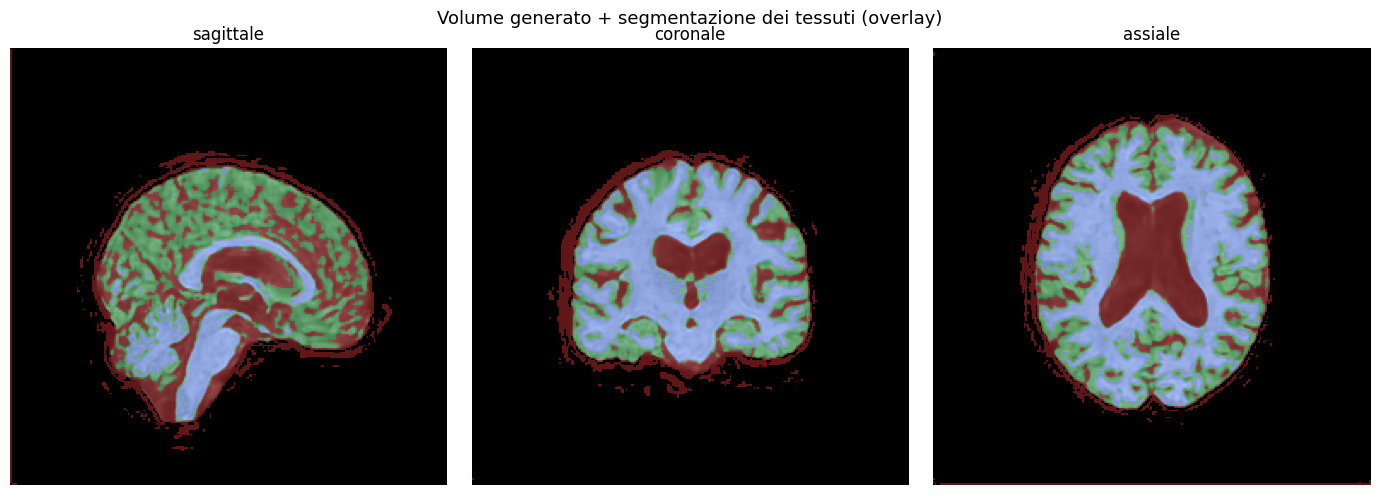

In [4]:
def show_overlay(base, idx=128, alpha=0.45):
    synth=load(f"{GEN_DIR}/{base}_synth.nii.gz")
    seg=load(f"{GEN_DIR}/{base}_synth_pveseg.nii.gz")

    fig, axes=plt.subplots(1, 3, figsize=(14,5))
    for j,(s,g,name) in enumerate(zip(views(synth,idx), views(seg,idx),
                                      ["sagittale","coronale","assiale"])):
        axes[j].imshow(s, cmap="gray")
        axes[j].imshow(np.ma.masked_where(g==0, g), cmap=TISSUE_CMAP,
                       vmin=0, vmax=3, alpha=alpha, interpolation="nearest")
        axes[j].set_title(name); axes[j].axis("off")
    fig.suptitle("Volume generato + segmentazione dei tessuti (overlay)", fontsize=13)
    plt.tight_layout(); plt.show()

show_overlay(base)

## Condizioni diverse, generazioni diverse

Il test che mostra che il condizionamento **funziona davvero**: maschere di soggetti diversi
producono cervelli diversi, ciascuno conforme alla propria condizione. Se il modello ignorasse
la maschera, i volumi generati sarebbero simili tra loro a prescindere dalla condizione.

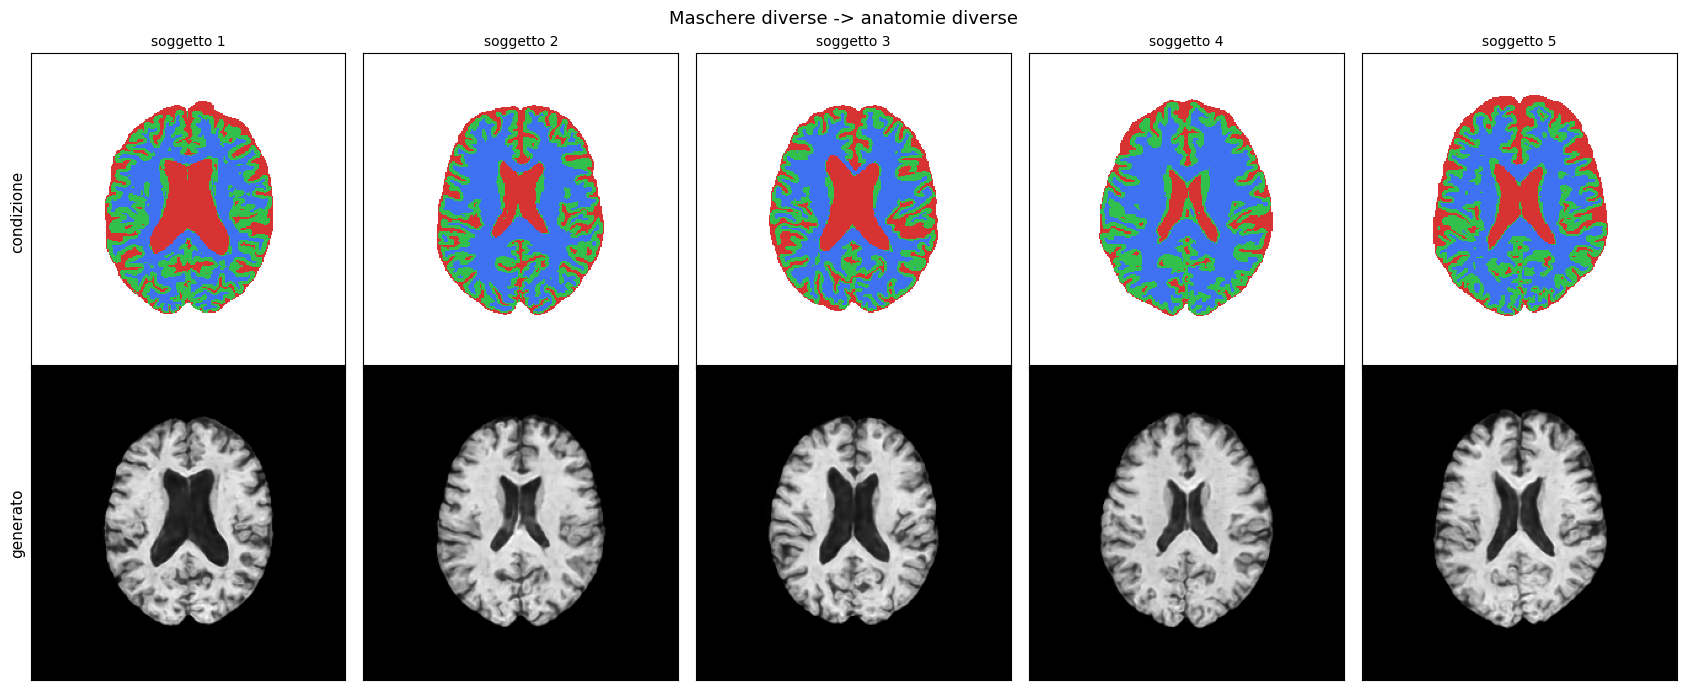

In [5]:
def show_grid(bases, idx=128, plane=2):
    """griglia: una colonna per soggetto, maschera sopra e generato sotto"""
    n=len(bases)
    fig, axes=plt.subplots(2, n, figsize=(3.4*n, 7))
    for i,b in enumerate(bases):
        m=views(load(f"{GEN_DIR}/{b}_condmask.nii.gz"), idx)[plane]
        s=views(load(f"{GEN_DIR}/{b}_synth.nii.gz"), idx)[plane]
        axes[0,i].imshow(m, cmap=TISSUE_CMAP, vmin=0, vmax=3, interpolation="nearest")
        axes[0,i].set_title(f"soggetto {i+1}", fontsize=10)
        axes[1,i].imshow(s, cmap="gray")
    axes[0,0].set_ylabel("condizione", fontsize=11)
    axes[1,0].set_ylabel("generato", fontsize=11)
    for a in axes.ravel(): a.set_xticks([]); a.set_yticks([])
    fig.suptitle("Maschere diverse -> anatomie diverse", fontsize=13)
    plt.tight_layout(); plt.show()

bases=[os.path.basename(c).replace("_synth.nii.gz","") for c in cases[:5]]
show_grid(bases)

## Piu' fette dello stesso volume

Il condizionamento e' **tridimensionale**: la coerenza non riguarda una singola fetta ma
l'intero volume. Qui piu' livelli assiali dello stesso caso, maschera e generato.

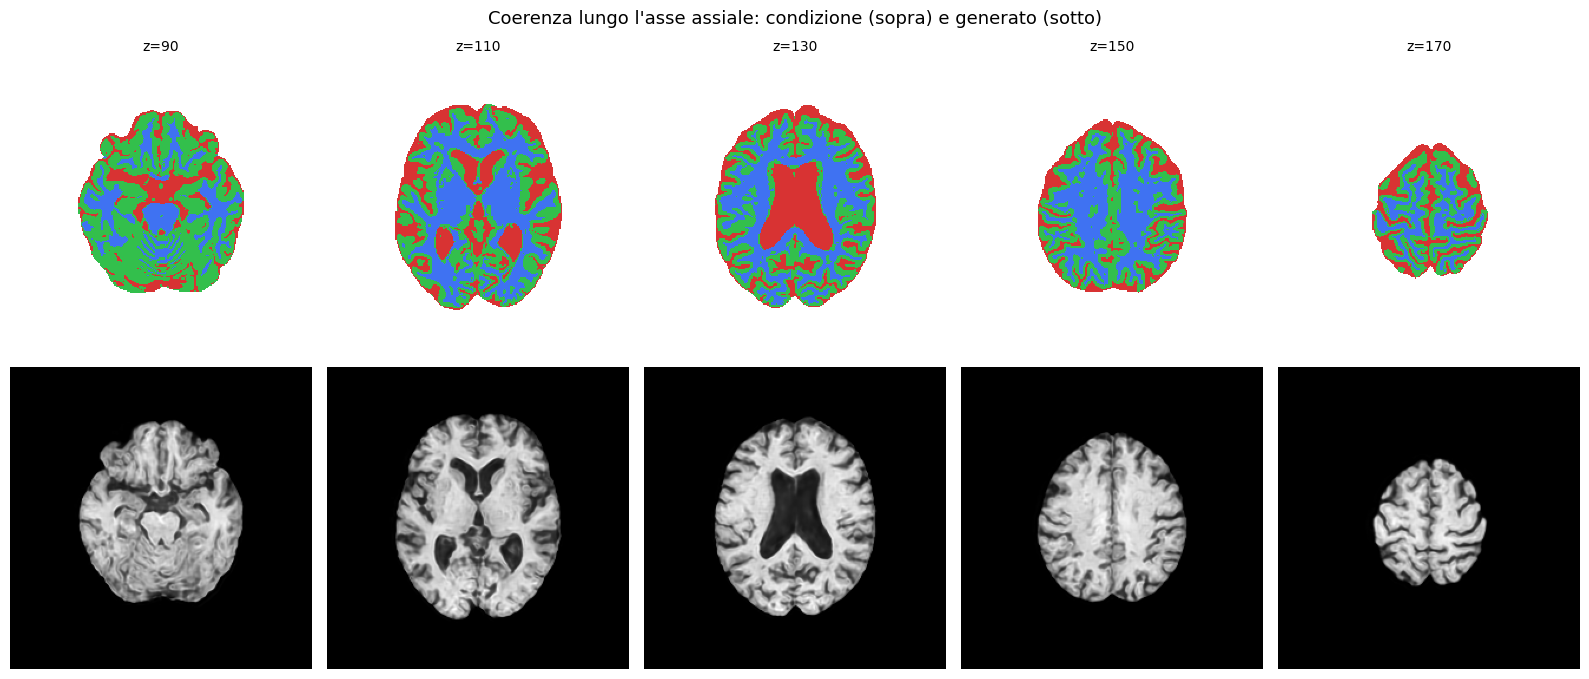

In [6]:
def show_slices(base, slices=(90,110,130,150,170), plane=2):
    mask=load(f"{GEN_DIR}/{base}_condmask.nii.gz")
    synth=load(f"{GEN_DIR}/{base}_synth.nii.gz")
    n=len(slices)
    fig, axes=plt.subplots(2, n, figsize=(3.2*n, 7))
    for i,z in enumerate(slices):
        m=np.rot90(mask[:,:,z]); s=np.rot90(synth[:,:,z])
        axes[0,i].imshow(m, cmap=TISSUE_CMAP, vmin=0, vmax=3, interpolation="nearest")
        axes[0,i].set_title(f"z={z}", fontsize=10)
        axes[1,i].imshow(s, cmap="gray")
    for a in axes.ravel(): a.axis("off")
    fig.suptitle("Coerenza lungo l'asse assiale: condizione (sopra) e generato (sotto)", fontsize=13)
    plt.tight_layout(); plt.show()

show_slices(base)

## Osservazioni

I volumi generati mostrano anatomia riconoscibile e coerente con la maschera: ventricoli,
corteccia con solchi, separazione tra materia grigia e bianca. Maschere diverse producono
anatomie diverse — il condizionamento e' effettivo, non ignorato.

La segmentazione dei volumi generati richiede una nota tecnica: i volumi decodificati vanno
salvati **senza clipping** a `[0,1]`. Il clipping accumula centinaia di migliaia di voxel
contro il limite superiore, il che rompe l'inizializzazione k-means di FSL-FAST
(`variance nan`) e fa collassare la segmentazione a 2 classi. Salvati nel loro range nativo
(qui fino a ~1.33) i volumi vengono segmentati direttamente, senza rumore aggiunto.

La valutazione quantitativa — DSC, selezione del checkpoint e tetto della misura — e' nel
**notebook 6**.